In [ ]:
from torch_brain.data import Data
import matplotlib.pyplot as plt
import h5py
import matplotlib.patches as mpatches

In [2]:
path = "/home/mila/s/sobralm/auditorydecoding/data/processed/neurosoft_minipigs_2026/sub-03_ses-04_task-AcousStim_acq-LHanest_desc-raw.h5"

with h5py.File(path) as f:
    data = Data.from_hdf5(f, lazy=False)

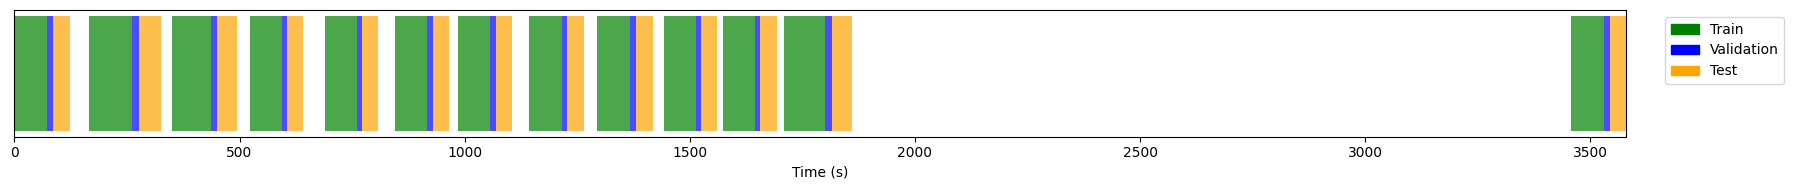

In [3]:
train_splits = data.splits.on_vs_off_causal_train
valid_splits = data.splits.on_vs_off_causal_valid
test_splits = data.splits.on_vs_off_causal_test

fig, ax = plt.subplots(figsize=(18, 2))

y = 0

# Plot train intervals (green)
for start, end in zip(train_splits.start, train_splits.end):
    ax.barh(y, end - start, left=start, height=0.5, color="green", alpha=0.7)

# Plot valid intervals (blue)
for start, end in zip(valid_splits.start, valid_splits.end):
    ax.barh(y, end - start, left=start, height=0.5, color="blue", alpha=0.7)

# Plot test intervals (orange)
for start, end in zip(test_splits.start, test_splits.end):
    ax.barh(y, end - start, left=start, height=0.5, color="orange", alpha=0.7)

ax.set_xlabel("Time (s)")
ax.set_yticks([])
ax.set_xlim([
    min(
        train_splits.start.min(),
        valid_splits.start.min(),
        test_splits.start.min(),
    ),
    max(
        train_splits.end.max(),
        valid_splits.end.max(),
        test_splits.end.max(),
    ),
])

# Make legend
legend_handles = [
    mpatches.Patch(color="green", label="Train"),
    mpatches.Patch(color="blue", label="Validation"),
    mpatches.Patch(color="orange", label="Test"),
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()